# Model Selection for scRNA-seq Analysis

This notebook shows how to run all models on a subset of real scRNA-seq data and use AIC to do model selection. We find ZINB achieves the highest log likelihood and the lowest AIC among 7 models.

In [1]:
import sys
sys.path.insert(0, '/nfs/roberts/project/pi_skr2/eng26/scmpra/tabula-rasa')
import scMPRAforge as scm

2026-03-26 11:11:41.420675: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from countmodels.models.poi import Poi
from countmodels.models.nb import NB
from countmodels.models.poih import PoiH
from countmodels.models.nbh import NBH
from countmodels.models.zipoi import ZIPoi
from countmodels.models.zinb import ZINB
from countmodels.models.mast import MAST

import numpy as np
import pandas as pd
import time
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from tensorzinb.utils import correct_pvalues_for_multiple_testing,normalize_features
from countmodels.utils import find_independent_columns,gen_feature_df

# import scMPRAforge as scm
import scipy.stats as stats

plt.style.use('seaborn-v0_8-muted')
sns.set_context('talk')

In [3]:
#create dask cluster
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client = Client(cluster)

## Preparation

In [4]:
model_classes = [Poi, NB, ZIPoi, ZINB]

methods={
    Poi: ['statsmodels'],
    NB: ['statsmodels','tensorflow'],
    ZIPoi: ['statsmodels'],
    ZINB: ['tensorflow'],
}

load data

In [8]:
path="/nfs/roberts/project/pi_skr2/shared/tabula_data/shendure"
name="ortho_primordial_v4"
precomp_name = 'ortho_primordial_v4_precomp_test_opg'

import os
if os.path.isdir(path+"/"+precomp_name):
    print("[+]PreComp Model found. Loading...")
    primordial=scm.ortho.load(client,path,precomp_name)
    shendure=primordial.training_data
elif os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
    primordial.precompute_wald(client, cov_method="opg")
    primordial.save(path, precomp_name) 

[+]PreComp Model found. Loading...


In [9]:
cres = list(primordial.by_cre_design.keys())
cell_types = list(primordial.by_cell_type_design.keys())
cell_types

['SurfaceEctoderm',
 'NeuroectodermBrain',
 'EpiblastPrimitiveStreak',
 'reference',
 'ExEndodermVisceral',
 'Mesoderm',
 'Cardiomyocytes',
 'ExEndodermParietal',
 'Haematoendothelial',
 'NeuroectodermRostral']

In [10]:
shendure.data.cell_bc.nunique()

43389

In [11]:
shendure.data.cre_id.nunique()

208

## run all models on sample data

In [12]:
import datetime

suffix = datetime.date.today().strftime("%m_%d_%Y")


In [13]:
# model_path = "./models"

# pickle_name = "model_selection_by_cell_type_{}.pickle".format(suffix)
# rs = []
# k = 0
# design = primordial.by_cell_type_design
# zinb_models = primordial.by_cell_type.model
# zinb_params = primordial.by_cell_type_parameters
# for cluster in design.keys():
#     print(f"\n[Cluster] {cluster}")
#     design_c = design[cluster].result()
#     endog      = design_c['regressand'].values
#     exog       = design_c['nb_regressors'].values
#     exog_infl  = design_c['zi_regressors'].values

#     for model_class in model_classes:
#         print(f"  Model: {model_class.__name__}")

#         # Handle your own ZINB
#         if model_class == ZINB:
#             print("  Using pre-fit ZINB")
#             zinb_res = zinb_models[cluster].result()
#             params = zinb_params.nb[cluster]

#             r = {"params": zinb_res["weights"],
#                 "llf": zinb_res["llf_total"],
#                 "aic": zinb_res["aic_total"],
#                 "df": zinb_res.get("df_model_total", zinb_res.get("df")),
#                 "cpu_time": zinb_res["cpu_time"],
#                 "model": "ZINB",
#                 "method": "tensorflow",   # or whatever label you prefer
#                 "cluster": cluster
#             }

#             rs.append(r)

#             # rs.append(r)
#         else:
#             if model_class not in methods:
#                 continue
#             else:
        
#                 mod = model_class(
#                     endog,
#                     exog,
#                     exog_infl=exog_infl,
#                     model_path=model_path
#                 )

#             for method in methods[model_class]:
#                 print(f"    Method: {method}")
                
#                 r = mod.fit(method=method)
#                 # attach metadata
#                 for t in r:
#                     t["cluster"] = cluster
#                     rs.append(t)

#         with open(pickle_name, "wb") as output_file:
#             pickle.dump(rs, output_file)

# with open(pickle_name, "wb") as output_file:
#     pickle.dump(rs, output_file)


# model_path = "./models"

# pickle_name = "model_selection_by_cre_{}.pickle".format(suffix)
# rs = []
# k = 0
# design = primordial.by_cre_design
# zinb_models = primordial.by_cre.model
# zinb_params = primordial.by_cre_parameters
# for cluster in design.keys():
#     print(f"\n[Cluster] {cluster}")
#     design_c = design[cluster].result()
#     endog      = design_c['regressand'].values
#     exog       = design_c['nb_regressors'].values
#     exog_infl  = design_c['zi_regressors'].values

#     for model_class in model_classes:
#         print(f"  Model: {model_class.__name__}")

#         # Handle your own ZINB
#         if model_class == ZINB:
#             print("  Using pre-fit ZINB")
#             zinb_res = zinb_models[cluster].result()
#             params = zinb_params.nb[cluster]

#             r = {"params": zinb_res["weights"],
#                 "llf": zinb_res["llf_total"],
#                 "aic": zinb_res["aic_total"],
#                 "df": zinb_res.get("df_model_total", zinb_res.get("df")),
#                 "cpu_time": zinb_res["cpu_time"],
#                 "model": "ZINB",
#                 "method": "tensorflow",   # or whatever label you prefer
#                 "cluster": cluster
#             }

#             rs.append(r)

#             # rs.append(r)
#         else:
#             if model_class not in methods:
#                 continue
#             else:
        
#                 mod = model_class(
#                     endog,
#                     exog,
#                     exog_infl=exog_infl,
#                     model_path=model_path
#                 )

#             for method in methods[model_class]:
#                 print(f"    Method: {method}")
                
#                 r = mod.fit(method=method)
#                 # attach metadata
#                 for t in r:
#                     t["cluster"] = cluster
#                     rs.append(t)

#         with open(pickle_name, "wb") as output_file:
#             pickle.dump(rs, output_file)

# with open(pickle_name, "wb") as output_file:
#     pickle.dump(rs, output_file)

In [14]:
pickle_name = "model_selection_by_cre_03_02_2026.pickle"

with open(pickle_name, "rb") as input_file:
    rs_cre = pickle.load(input_file)

pickle_name = "model_selection_by_cell_type_03_02_2026.pickle"

with open(pickle_name, "rb") as input_file:
    rs_cell_type = pickle.load(input_file)

In [15]:
df_results_cre = pd.DataFrame(rs_cre)
df_results_cre['split'] = 'by_cre'

df_results_cell_type = pd.DataFrame(rs_cell_type)
df_results_cell_type['split'] = 'by_cell_type'

In [16]:
df_results_cell_type.shape

(40, 9)

In [17]:
dfr=pd.concat([df_results_cre, df_results_cell_type])
dfr
order=['poi','zipoi','nb', 'ZINB']

## plot AIC

we find ZINB attains the lowest AIC.

In [18]:
dfr=pd.concat([df_results_cre, df_results_cell_type]).reset_index(drop=True)
dfr


,params,llf,df,aic,cpu_time,model,method,cluster,split
0,"[1.343734746701094, -2.9899866322579105, -0.55...",-17931.354932,10,35882.709864,0.003399,poi,statsmodels,Txndc12_chr4_7978,by_cre
1,"[1.343944, -2.9897866, -0.5545985, -1.7348732,...",-6463.119450,11,12948.238899,0.291639,nb,tensorflow,Txndc12_chr4_7978,by_cre
2,"[0.7454151078436461, 0.7557487823110173, 1.220...",-12187.241005,16,24406.482009,0.146459,zipoi,statsmodels,Txndc12_chr4_7978,by_cre
3,"{'x_mu': [1.4336342811584473, -2.9309008121490...",-6451.142887,17,12936.285774,10.421936,ZINB,tensorflow,Txndc12_chr4_7978,by_cre
4,"[-4.264438892446496, 3.268105452898805, -0.561...",-265.710299,4,539.420597,0.001169,poi,statsmodels,Klf4_chr4_3952,by_cre
...,...,...,...,...,...,...,...,...,...
867,"{'x_mu': [-3.2952470779418945, 3.2814049720764...",-16968.125465,98,34132.250930,27.355906,ZINB,tensorflow,Haematoendothelial,by_cell_type
868,"[-4.1624050995793835, 4.089379964564493, 5.240...",-54389.900355,85,108949.800711,0.224550,poi,statsmodels,NeuroectodermRostral,by_cell_type
869,"[-4.162804, 4.0888486, 5.240112, 2.6127558, 2....",-16997.657878,86,34167.315757,1.591092,nb,tensorflow,NeuroectodermRostral,by_cell_type
870,"[-0.7205679198315794, -0.4095272685460484, -0....",-45333.363377,91,90848.726754,3.318040,zipoi,statsmodels,NeuroectodermRostral,by_cell_type


In [19]:
dfr
dfr["aic"] = pd.to_numeric(dfr["aic"])
# Define the "task" grouping
task_cols = ["split", "cluster"]
# Min AIC per task
dfr["min_aic_task"] = dfr.groupby(task_cols)["aic"].transform("min")


# ΔAIC per row (model) within its task
dfr["delta_aic"] = dfr["aic"] - dfr["min_aic_task"]
winners = (
    dfr.loc[dfr.groupby(task_cols)["aic"].idxmin(), task_cols + ["model", "aic"]]
      .rename(columns={"model": "winner_model", "aic": "winner_aic"})
)

# Count wins overall (or by split)
win_counts = winners["winner_model"].value_counts()
win_counts_by_split = winners.groupby("split")["winner_model"].value_counts()
pd.DataFrame(win_counts_by_split)

count
split        winner_model       
by_cell_type nb                8
             ZINB              2
by_cre       nb              149
             ZINB             44
             zipoi            14
             poi               1

In [20]:
df = dfr.copy()
df_nb = df[df["model"]=="nb"]
df_zinb = df[df["model"]=="ZINB"]

merged = df_nb.merge(
    df_zinb,
    on=["split","cluster"],
    suffixes=("_nb","_zinb")
)

merged["delta_nb_vs_zinb"] = merged["aic_nb"] - merged["aic_zinb"]

merged["delta_nb_vs_zinb"].describe()

count     218.000000
mean        8.641583
std       120.309764
min       -53.963623
25%        -8.811440
50%        -5.049500
75%        -0.159210
max      1360.000000
Name: delta_nb_vs_zinb, dtype: float64

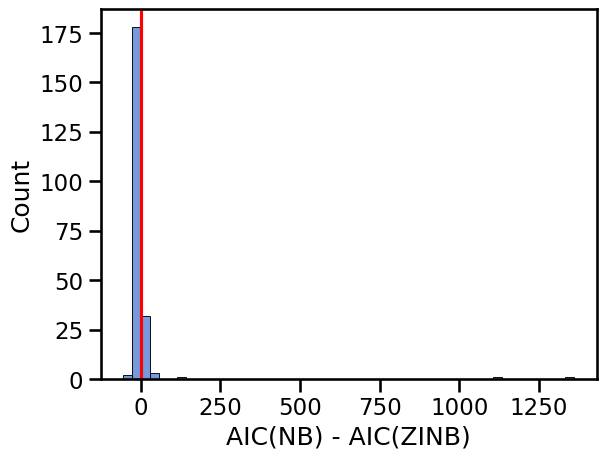

In [21]:
sns.histplot(merged["delta_nb_vs_zinb"], bins=50)
plt.axvline(0, color="red")
plt.xlabel("AIC(NB) - AIC(ZINB)")
plt.show()

In [22]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(merged["delta_nb_vs_zinb"])
print(p)

2.2319317355121962e-11


In [23]:
dfr.groupby(["split","model"])["delta_aic"].median()

split         model
by_cell_type  ZINB          8.406250
              nb            0.000000
              poi      596242.665192
              zipoi    419009.931405
by_cre        ZINB          4.984753
              nb            0.000000
              poi         413.199522
              zipoi        69.802653
Name: delta_aic, dtype: float64

In [24]:
df_aic = dfr.groupby(['split', 'cluster','model'])['aic'].min().reset_index()
df_aic['not_nan']=1-np.isnan(df_aic['aic'])
df_aic['cnt']=df_aic.groupby(['split', 'cluster']).transform('sum')['not_nan']
dfp=df_aic[df_aic['cnt']==4].copy()
min_aic = dfp.groupby('model').aic.mean().min()
# dfp['aic']=dfp['aic']-min_aic
dfp.groupby('model').aic.mean()

model
ZINB     11162.518684
nb       11171.160267
poi      73257.513994
zipoi    58862.408495
Name: aic, dtype: float64

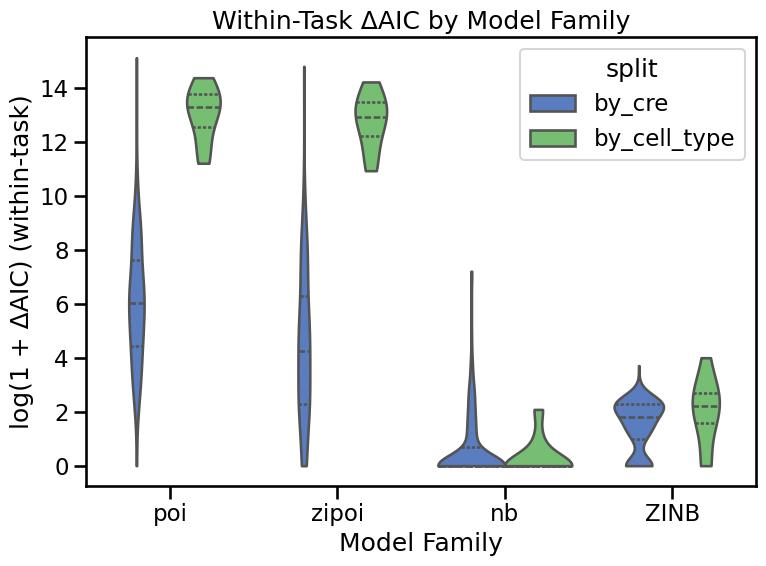

In [25]:
dfr = dfr.copy()
dfr["delta_aic_log1p"] = np.log1p(dfr["delta_aic"])

plt.figure(figsize=(8,6))
sns.violinplot(
    data=dfr,
    x="model",
    y="delta_aic_log1p",
    hue="split",
    order=order,
    cut=0,
    inner="quartile",
    density_norm="area",
    common_norm=False,   # important: don't let by_cre dominate by_cell_type
)
plt.ylabel("log(1 + ΔAIC) (within-task)")
plt.xlabel("Model Family")
plt.title("Within-Task ΔAIC by Model Family")
plt.tight_layout()
plt.show()

In [26]:
import itertools

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "ns"

def paired_tests_by_split(dfr, models, task_cols=("cluster",), split_col="split",
                          value_col="delta_aic", test="ttest"):
    """
    Returns a DataFrame of paired tests for each split and each model pair.
    Pairing is done within each task (split + task_cols).
    """
    out = []
    for split, g in dfr.groupby(split_col):
        # wide: one row per task, one column per model
        wide = g.pivot_table(index=list(task_cols), columns="model", values=value_col, aggfunc="first")
        # keep only tasks with all models available
        wide = wide.dropna(subset=models, how="any")

        for a, b in itertools.combinations(models, 2):
            x = wide[a].to_numpy()
            y = wide[b].to_numpy()
            if len(x) < 3:
                continue

            if test == "ttest":
                # paired t-test on differences
                res = stats.ttest_rel(x, y, nan_policy="omit")
                p = res.pvalue
                stat = res.statistic
                name = "paired t"
            elif test == "wilcoxon":
                # wilcoxon signed-rank (nonparametric)
                # requires non-identical pairs; handle all-zero diffs
                diffs = x - y
                if np.allclose(diffs, 0):
                    p, stat = 1.0, 0.0
                else:
                    stat, p = stats.wilcoxon(diffs)
                name = "wilcoxon"
            else:
                raise ValueError("test must be 'ttest' or 'wilcoxon'")

            out.append({
                "split": split,
                "model_a": a,
                "model_b": b,
                "n_tasks": len(x),
                "test": name,
                "stat": float(stat),
                "p": float(p),
                "stars": p_to_stars(p),
                "mean_diff": float(np.mean(x - y)),  # positive => a > b (worse if using ΔAIC)
            })

    return pd.DataFrame(out)

In [27]:
order = ["poi", "zipoi", "nb", "ZINB"]
tests = paired_tests_by_split(
    dfr,
    models=order,
    task_cols=("cluster",),        # tasks are clusters within each split
    value_col="delta_aic",         # use raw ΔAIC for the test
    test="wilcoxon"                   # or "wilcoxon"
)
tests_sig = tests[tests["p"] < 0.05]
tests_sig.sort_values(["split","p"]).head()

,split,model_a,model_b,n_tasks,test,stat,p,stars,mean_diff
0,by_cell_type,poi,zipoi,10,wilcoxon,0.0,0.001953,**,152132.896078
1,by_cell_type,poi,nb,10,wilcoxon,0.0,0.001953,**,675075.551976
2,by_cell_type,poi,ZINB,10,wilcoxon,0.0,0.001953,**,675064.068831
3,by_cell_type,zipoi,nb,10,wilcoxon,0.0,0.001953,**,522942.655897
4,by_cell_type,zipoi,ZINB,10,wilcoxon,0.0,0.001953,**,522931.172753


In [28]:
tests

,split,model_a,model_b,n_tasks,test,stat,p,stars,mean_diff
0,by_cell_type,poi,zipoi,10,wilcoxon,0.0,1.953125e-03,**,152132.896078
1,by_cell_type,poi,nb,10,wilcoxon,0.0,1.953125e-03,**,675075.551976
2,by_cell_type,poi,ZINB,10,wilcoxon,0.0,1.953125e-03,**,675064.068831
3,by_cell_type,zipoi,nb,10,wilcoxon,0.0,1.953125e-03,**,522942.655897
4,by_cell_type,zipoi,ZINB,10,wilcoxon,0.0,1.953125e-03,**,522931.172753
5,by_cell_type,nb,ZINB,10,wilcoxon,6.0,2.734375e-02,*,-11.483144
6,by_cre,poi,zipoi,208,wilcoxon,17.0,8.968866e-36,****,7773.096337
7,by_cre,poi,nb,208,wilcoxon,2.0,7.219288e-36,****,32615.719196
8,by_cre,poi,ZINB,208,wilcoxon,32.0,1.113915e-35,****,32625.328314
9,by_cre,zipoi,nb,208,wilcoxon,351.0,1.042122e-33,****,24842.622859


In [29]:

def annotate_pairwise_brackets(ax, tests_df, order, split_order, split_palette,
                               y_base, y_step, use_stars=True):
    """
    Draw brackets for each split separately, above the violins.
    y_base and y_step are in axis units of the plotted y (here: log1p scale).
    """
    # hue offsets: for 2 splits, seaborn typically uses +/- 0.2 around center
    # We'll compute offsets based on number of splits:
    n_hue = len(split_order)
    # approximate spacing used by seaborn for hue dodging
    # width for violinplot default is ~0.8; split positions divide that.
    dodge = 0.8 / n_hue
    offsets = {split: (-0.4 + dodge/2 + i*dodge) for i, split in enumerate(split_order)}

    # per x-category center positions are 0..len(order)-1
    x_pos = {m: i for i, m in enumerate(order)}

    # draw for each split
    for split in split_order:
        sub = tests_df[tests_df["split"] == split].copy()
        # order pairs in a consistent way: shortest span first
        sub["span"] = sub.apply(lambda r: abs(x_pos[r["model_a"]] - x_pos[r["model_b"]]), axis=1)
        sub = sub.sort_values(["span", "p"])
        y = y_base

        color = split_palette[split]
        for _, r in sub.iterrows():
            a = r["model_a"]; b = r["model_b"]
            x1 = x_pos[a] + offsets[split]
            x2 = x_pos[b] + offsets[split]
            if x1 > x2:
                x1, x2 = x2, x1

            # bracket
            ax.plot([x1, x1, x2, x2], [y, y+y_step*0.2, y+y_step*0.2, y], lw=1.2, color=color)

            label = r["stars"] if use_stars else f"p={r['p']:.1e}"
            ax.text((x1+x2)/2, y+y_step*0.25, label, ha="center", va="bottom", color=color, fontsize=10)
            y += y_step

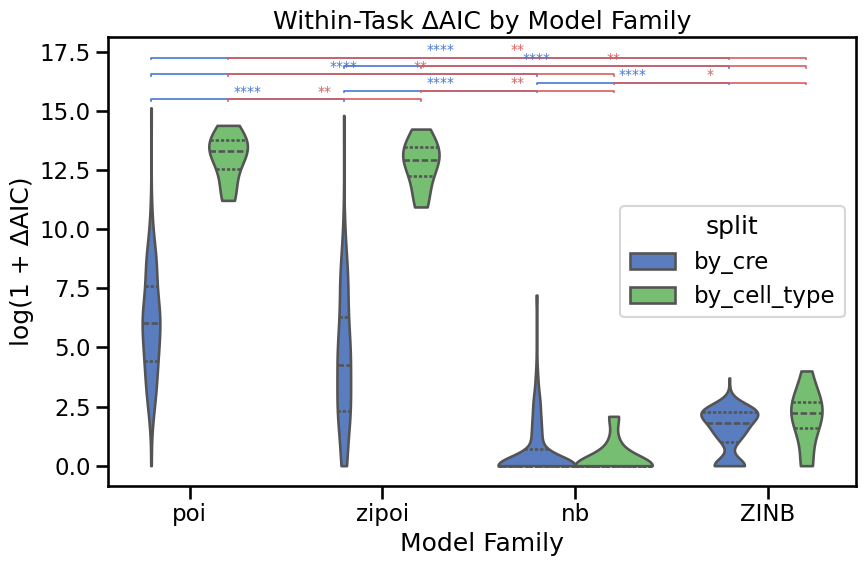

In [30]:
dfr_plot = dfr.copy()
dfr_plot["delta_aic_log1p"] = np.log1p(dfr_plot["delta_aic"])

plt.figure(figsize=(9,6))

ax = sns.violinplot(
    data=dfr_plot,
    x="model",
    y="delta_aic_log1p",
    hue="split",
    order=order,
    cut=0,
    inner="quartile",
    density_norm="area",
    common_norm=False
)

ax.set_ylabel("log(1 + ΔAIC)")
ax.set_xlabel("Model Family")
ax.set_title("Within-Task ΔAIC by Model Family")

annotate_pairwise_brackets(
    ax,
    tests_df=tests_sig,
    order=order,
    split_order=["by_cre","by_cell_type"],
    split_palette={"by_cre":"C0","by_cell_type":"C2"},
    y_base=dfr_plot["delta_aic_log1p"].max() + 0.3,
    y_step=0.35
)

plt.tight_layout()
plt.show()

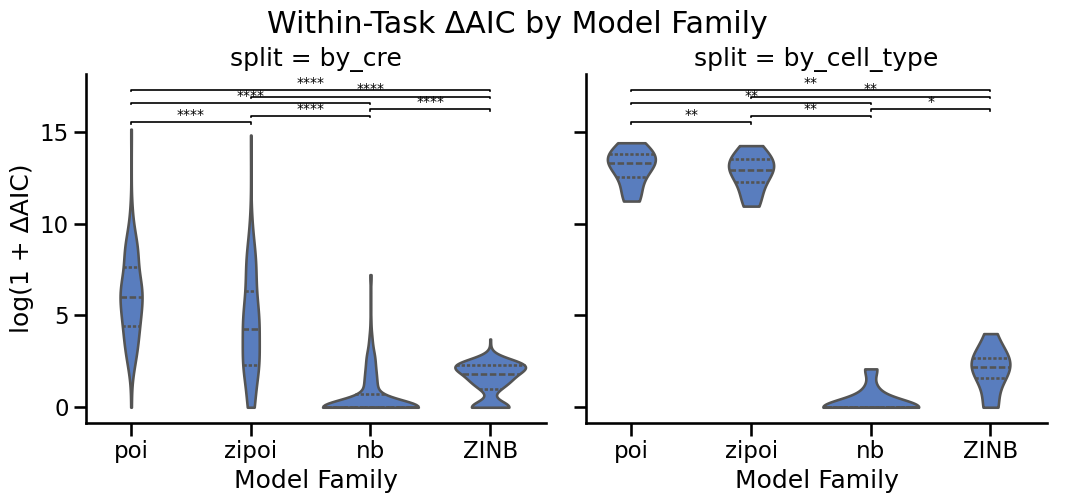

In [31]:
g = sns.catplot(
    data=dfr_plot,
    x="model",
    y="delta_aic_log1p",
    col="split",
    order=order,
    kind="violin",
    inner="quartile",
    density_norm="area",
    cut=0,
    sharey=True,
    height=5,
    aspect=1.1
)

for split, ax in g.axes_dict.items():

    sub_tests = tests_sig[tests_sig["split"] == split]

    annotate_pairwise_brackets(
        ax,
        tests_df=sub_tests,
        order=order,
        split_order=[split],
        split_palette={split:"black"},
        y_base=dfr_plot["delta_aic_log1p"].max() + 0.3,
        y_step=0.35
    )

g.set_axis_labels("Model Family", "log(1 + ΔAIC)")
g.fig.suptitle("Within-Task ΔAIC by Model Family", y=1.02)

plt.show()

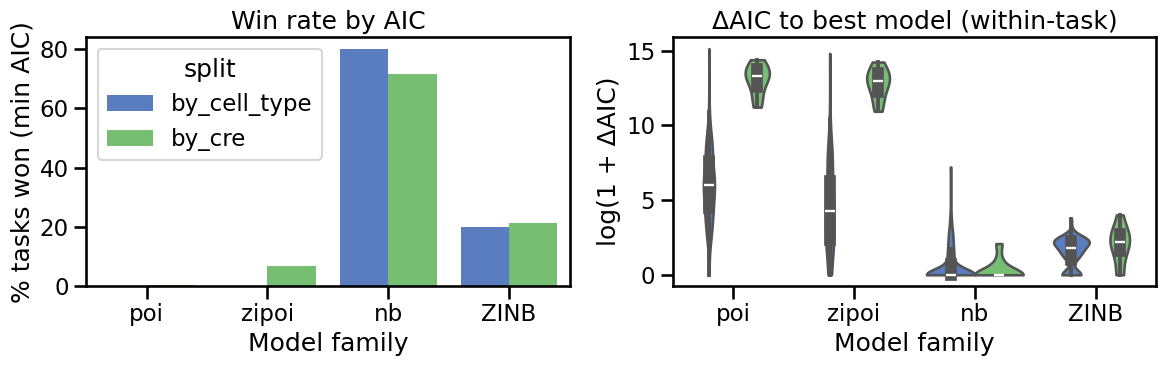

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Win-rate table
win_rate = (
    winners.groupby(["split","winner_model"])
           .size()
           .reset_index(name="n")
)
win_rate["pct"] = win_rate.groupby("split")["n"].transform(lambda x: 100 * x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

# Left: Win rate
sns.barplot(
    data=win_rate,
    x="winner_model", y="pct",
    hue="split",
    order=order,
    ax=axes[0]
)
axes[0].set_xlabel("Model family")
axes[0].set_ylabel("% tasks won (min AIC)")
axes[0].set_title("Win rate by AIC")
axes[0].legend(title="split")

# Right: ΔAIC distributions (box is less busy than violin)
sns.violinplot(
    data=dfr,
    x="model", y="delta_aic_log1p",
    hue="split",
    order=order,
    ax=axes[1],
    cut=0
)
axes[1].set_xlabel("Model family")
axes[1].set_ylabel("log(1 + ΔAIC)")
axes[1].set_title("ΔAIC to best model (within-task)")
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

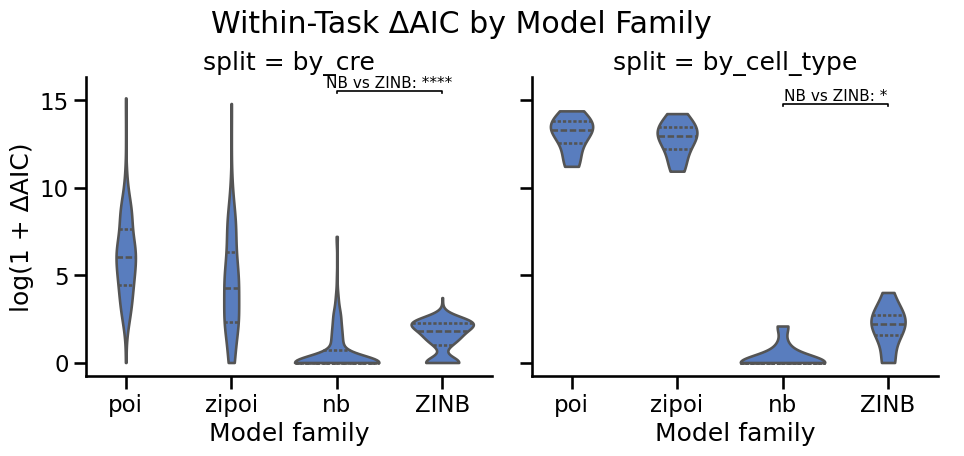

In [33]:
from scipy import stats

def paired_nb_vs_zinb_p(dfr, split, value_col="delta_aic"):
    wide = (dfr[dfr["split"]==split]
            .pivot_table(index="cluster", columns="model", values=value_col, aggfunc="first")
            .dropna(subset=["nb","ZINB"]))
    diffs = wide["nb"] - wide["ZINB"]
    # Wilcoxon is safer for your heavy-tailed differences
    stat, p = stats.wilcoxon(diffs) if not np.allclose(diffs, 0) else (0.0, 1.0)
    return p

def add_single_bracket(ax, x1, x2, y, text):
    ax.plot([x1, x1, x2, x2], [y, y+0.1, y+0.1, y], color="black", lw=1.2)
    ax.text((x1+x2)/2, y+0.12, text, ha="center", va="bottom", fontsize=11)

# Facet violins
g = sns.catplot(
    data=dfr,
    x="model", y="delta_aic_log1p",
    col="split",
    order=order,
    kind="violin",
    inner="quartile",
    cut=0,
    height=4.5,
    aspect=1.1
)

for split, ax in g.axes_dict.items():
    p = paired_nb_vs_zinb_p(dfr, split, value_col="delta_aic")
    stars = "****" if p < 1e-4 else "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"
    ymax = dfr[dfr["split"]==split]["delta_aic_log1p"].max()
    # x positions in order list:
    x_nb = order.index("nb")
    x_z = order.index("ZINB")
    add_single_bracket(ax, x_nb, x_z, ymax + 0.3, f"NB vs ZINB: {stars}")

g.set_axis_labels("Model family", "log(1 + ΔAIC)")
g.fig.suptitle("Within-Task ΔAIC by Model Family", y=1.03)
plt.show()

## plot log likelihood (expanded)

Mirror the AIC workflow using per-task log-likelihood gaps, where smaller `delta_llf` is better (0 = task winner).

In [34]:
dfr_ll = pd.concat([df_results_cre, df_results_cell_type]).reset_index(drop=True).copy()
dfr_ll["llf"] = pd.to_numeric(dfr_ll["llf"])
task_cols_llf = ["split", "cluster"]

# Best (max) log-likelihood per task
dfr_ll["max_llf_task"] = dfr_ll.groupby(task_cols_llf)["llf"].transform("max")

# ΔLLF gap to the within-task best model (0 is best)
dfr_ll["delta_llf"] = dfr_ll["max_llf_task"] - dfr_ll["llf"]

winners_llf = (
    dfr_ll.loc[dfr_ll.groupby(task_cols_llf)["llf"].idxmax(), task_cols_llf + ["model", "llf"]]
      .rename(columns={"model": "winner_model", "llf": "winner_llf"})
)

win_counts_llf = winners_llf["winner_model"].value_counts()
win_counts_llf_by_split = winners_llf.groupby("split")["winner_model"].value_counts()
pd.DataFrame(win_counts_llf_by_split)


count
split        winner_model       
by_cell_type ZINB              7
             nb                3
by_cre       ZINB            176
             zipoi            22
             nb               10

In [35]:
df_nb_llf = dfr_ll[dfr_ll["model"] == "nb"]
df_zinb_llf = dfr_ll[dfr_ll["model"] == "ZINB"]

merged_llf = df_nb_llf.merge(
    df_zinb_llf,
    on=["split", "cluster"],
    suffixes=("_nb", "_zinb")
)

# Positive means ZINB has higher LLF than NB
merged_llf["llf_gain_zinb_vs_nb"] = merged_llf["llf_zinb"] - merged_llf["llf_nb"]
merged_llf["llf_gain_zinb_vs_nb"].describe()


count    218.000000
mean      10.320792
std       60.154882
min      -20.981812
25%        1.594280
50%        3.475250
75%        5.920395
max      686.000000
Name: llf_gain_zinb_vs_nb, dtype: float64

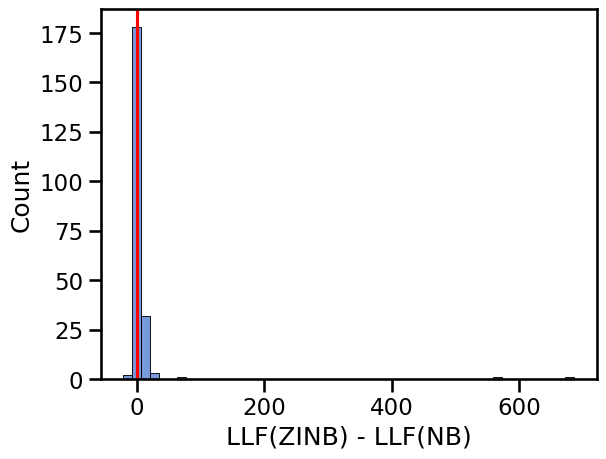

1.0302416638685626e-33


In [36]:
sns.histplot(merged_llf["llf_gain_zinb_vs_nb"], bins=50)
plt.axvline(0, color="red")
plt.xlabel("LLF(ZINB) - LLF(NB)")
plt.show()

stat_llf, p_llf = wilcoxon(merged_llf["llf_gain_zinb_vs_nb"])
print(p_llf)


In [37]:
dfr_ll.groupby(["split","model"])["delta_llf"].median()


split         model
by_cell_type  ZINB          0.000000
              nb            1.796875
              poi      298122.370998
              zipoi    209500.004104
by_cre        ZINB          0.000000
              nb            3.525196
              poi         212.967833
              zipoi        34.161594
Name: delta_llf, dtype: float64

In [38]:
dfr_ll_plot = dfr_ll.copy()
dfr_ll_plot["delta_llf_log1p"] = np.log1p(dfr_ll_plot["delta_llf"])

tests_llf = paired_tests_by_split(
    dfr_ll_plot,
    models=order,
    task_cols=("cluster",),
    value_col="delta_llf",
    test="wilcoxon"
)
tests_llf_sig = tests_llf[tests_llf["p"] < 0.05]
tests_llf_sig.sort_values(["split","p"]).head()


,split,model_a,model_b,n_tasks,test,stat,p,stars,mean_diff
0,by_cell_type,poi,zipoi,10,wilcoxon,0.0,0.001953,**,76072.448039
1,by_cell_type,poi,nb,10,wilcoxon,0.0,0.001953,**,337538.775988
2,by_cell_type,poi,ZINB,10,wilcoxon,0.0,0.001953,**,337539.034416
3,by_cell_type,zipoi,nb,10,wilcoxon,0.0,0.001953,**,261466.327949
4,by_cell_type,zipoi,ZINB,10,wilcoxon,0.0,0.001953,**,261466.586376


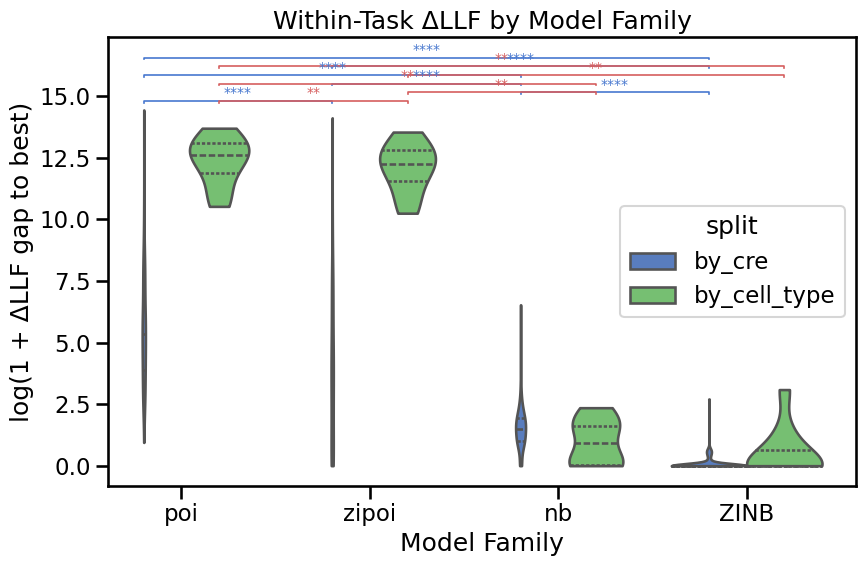

In [39]:
plt.figure(figsize=(9,6))

ax = sns.violinplot(
    data=dfr_ll_plot,
    x="model",
    y="delta_llf_log1p",
    hue="split",
    order=order,
    cut=0,
    inner="quartile",
    density_norm="area",
    common_norm=False
)

ax.set_ylabel("log(1 + ΔLLF gap to best)")
ax.set_xlabel("Model Family")
ax.set_title("Within-Task ΔLLF by Model Family")

annotate_pairwise_brackets(
    ax,
    tests_df=tests_llf_sig,
    order=order,
    split_order=["by_cre","by_cell_type"],
    split_palette={"by_cre":"C0","by_cell_type":"C2"},
    y_base=dfr_ll_plot["delta_llf_log1p"].max() + 0.3,
    y_step=0.35
)

plt.tight_layout()
plt.show()


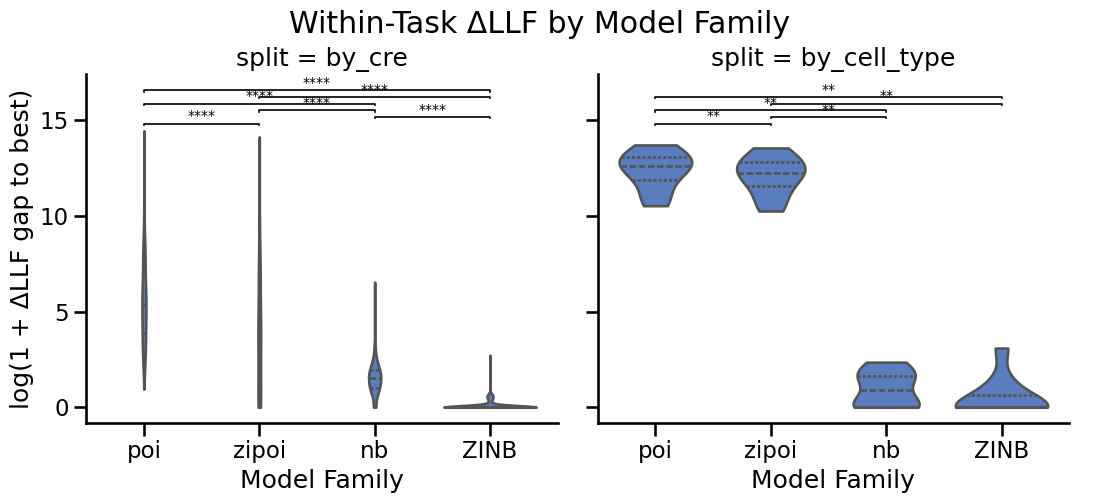

In [40]:
g_llf = sns.catplot(
    data=dfr_ll_plot,
    x="model",
    y="delta_llf_log1p",
    col="split",
    order=order,
    kind="violin",
    inner="quartile",
    density_norm="area",
    cut=0,
    sharey=True,
    height=5,
    aspect=1.1
)

for split, ax in g_llf.axes_dict.items():
    sub_tests = tests_llf_sig[tests_llf_sig["split"] == split]
    annotate_pairwise_brackets(
        ax,
        tests_df=sub_tests,
        order=order,
        split_order=[split],
        split_palette={split:"black"},
        y_base=dfr_ll_plot["delta_llf_log1p"].max() + 0.3,
        y_step=0.35
    )

g_llf.set_axis_labels("Model Family", "log(1 + ΔLLF gap to best)")
g_llf.fig.suptitle("Within-Task ΔLLF by Model Family", y=1.02)

plt.show()


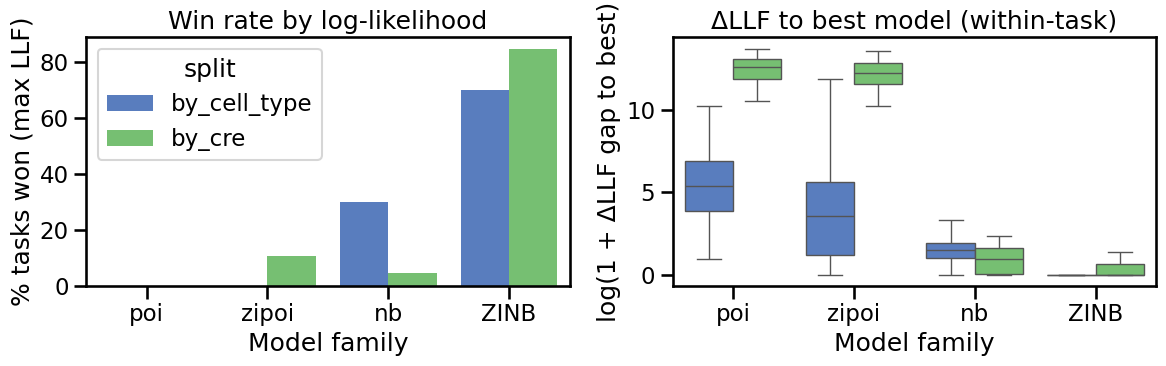

In [41]:
win_rate_llf = (
    winners_llf.groupby(["split","winner_model"])
               .size()
               .reset_index(name="n")
)
win_rate_llf["pct"] = win_rate_llf.groupby("split")["n"].transform(lambda x: 100 * x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

sns.barplot(
    data=win_rate_llf,
    x="winner_model", y="pct",
    hue="split",
    order=order,
    ax=axes[0]
)
axes[0].set_xlabel("Model family")
axes[0].set_ylabel("% tasks won (max LLF)")
axes[0].set_title("Win rate by log-likelihood")
axes[0].legend(title="split")

sns.boxplot(
    data=dfr_ll_plot,
    x="model", y="delta_llf_log1p",
    hue="split",
    order=order,
    ax=axes[1],
    showfliers=False
)
axes[1].set_xlabel("Model family")
axes[1].set_ylabel("log(1 + ΔLLF gap to best)")
axes[1].set_title("ΔLLF to best model (within-task)")
axes[1].legend_.remove()

plt.tight_layout()
plt.show()


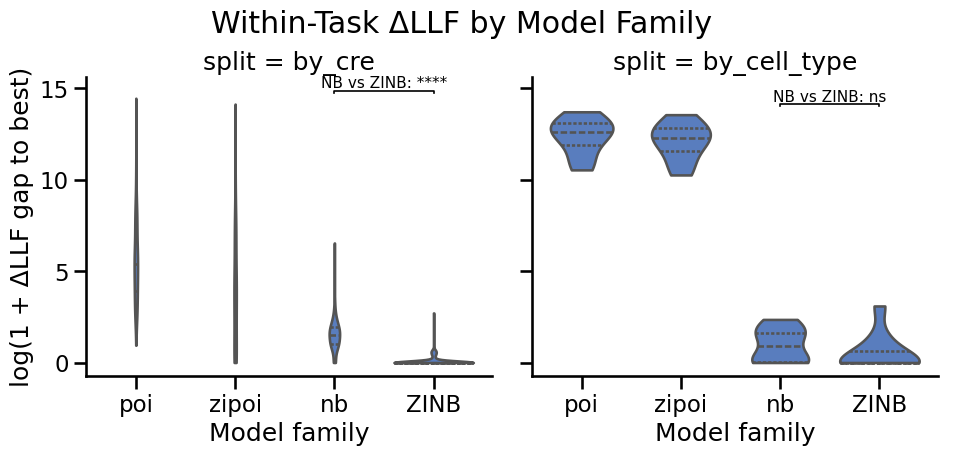

In [42]:
def paired_nb_vs_zinb_p_llf(dfr_ll_plot, split, value_col="delta_llf"):
    wide = (dfr_ll_plot[dfr_ll_plot["split"] == split]
            .pivot_table(index="cluster", columns="model", values=value_col, aggfunc="first")
            .dropna(subset=["nb","ZINB"]))
    diffs = wide["nb"] - wide["ZINB"]
    stat, p = stats.wilcoxon(diffs) if not np.allclose(diffs, 0) else (0.0, 1.0)
    return p

g = sns.catplot(
    data=dfr_ll_plot,
    x="model", y="delta_llf_log1p",
    col="split",
    order=order,
    kind="violin",
    inner="quartile",
    cut=0,
    height=4.5,
    aspect=1.1
)

for split, ax in g.axes_dict.items():
    p = paired_nb_vs_zinb_p_llf(dfr_ll_plot, split, value_col="delta_llf")
    stars = "****" if p < 1e-4 else "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"
    ymax = dfr_ll_plot[dfr_ll_plot["split"] == split]["delta_llf_log1p"].max()
    x_nb = order.index("nb")
    x_z = order.index("ZINB")
    add_single_bracket(ax, x_nb, x_z, ymax + 0.3, f"NB vs ZINB: {stars}")

g.set_axis_labels("Model family", "log(1 + ΔLLF gap to best)")
g.fig.suptitle("Within-Task ΔLLF by Model Family", y=1.03)
plt.show()


In [43]:
# fig, ax = plt.subplots(figsize=(12,6))
# sns.barplot(x="model", y='aic', data=dfp,ax=ax, errorbar=None, order=order)
# fig.suptitle('model AIC - min AIC', fontsize=15);
# ax.bar_label(ax.containers[0], fontsize=10)

# # ax.set_ylabel('');

## plot computing time

In [44]:
df_time= dfr.groupby(['split', 'cluster','model'])['cpu_time'].min().reset_index()
df_time['not_nan']=1-np.isnan(df_time['cpu_time'])
df_time['cnt']=df_time.groupby(['split', 'cluster']).transform('sum')['not_nan']
dfp=df_time[df_time['cnt']==4].copy()
min_time = dfp.groupby('model').cpu_time.mean().min()
dfp['cpu_time']=dfp['cpu_time']
dfp.groupby('model').cpu_time.mean()

model
ZINB     10.202243
nb        1.127677
poi       0.567549
zipoi     8.980828
Name: cpu_time, dtype: float64

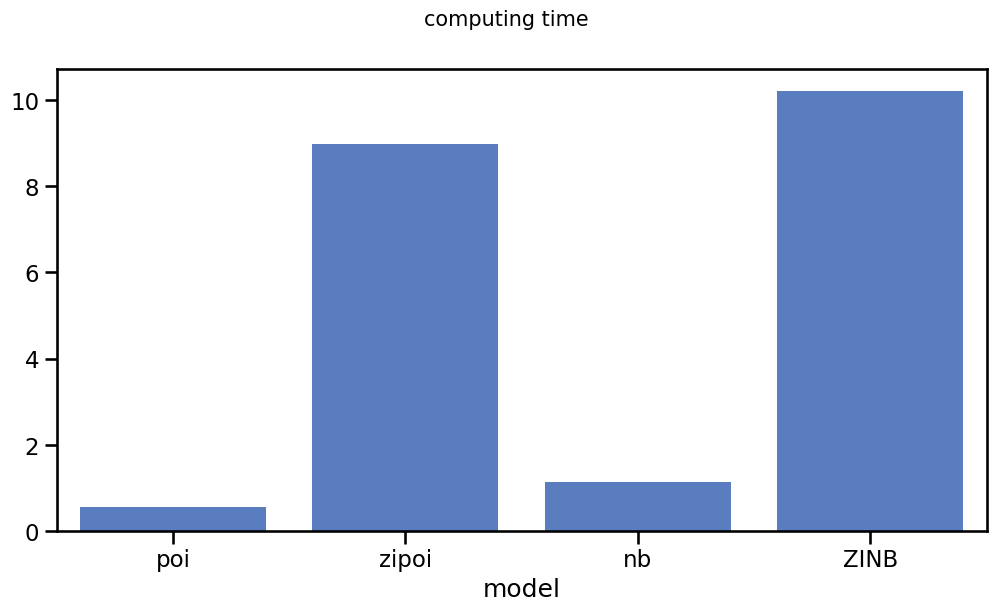

In [41]:
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x="model", y='cpu_time', data=dfp,ax=ax, errorbar=None, order=order)
fig.suptitle('computing time', fontsize=15);
ax.set_ylabel('');

## ZINB method compare

TensorZINB achieves the highest log likelihood with the lowest computing time.

In [16]:
df_zinb=dfr[dfr.model=='zinb'].copy()
df_zinb['not_nan']=1-np.isnan(df_zinb['llf'])
df_zinb['cnt']=df_zinb.groupby(['gene_id', 'cluster'])['not_nan'].transform('sum')
df_zinb[df_zinb['cnt']==3].groupby(['method'])['llf'].mean()

method
stan          -12824.727643
statsmodels   -13434.019255
tensorflow    -12764.196961
Name: llf, dtype: float64

In [17]:
df_zinb[df_zinb['cnt']==3].groupby(['method'])['cpu_time'].mean()

method
stan            5.234233
statsmodels    21.187485
tensorflow      0.821549
Name: cpu_time, dtype: float64

statsmodels fails to return results for most genes.